The goal of this task is to classify wines into one of three distinct categories (Class 0, 1, or 2)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the Wine dataset
wine = load_wine(as_frame=True)
df_wine = wine.frame

print(f"Data Shape (Rows, Columns): {df_wine.shape}\n")
display(df_wine.head())

Data Shape (Rows, Columns): (178, 14)



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Data Cleaning & Preprocessing

In [3]:
# Check for missing values
print( df_wine.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Exploratory Data Analysis (EDA) & Visualizations

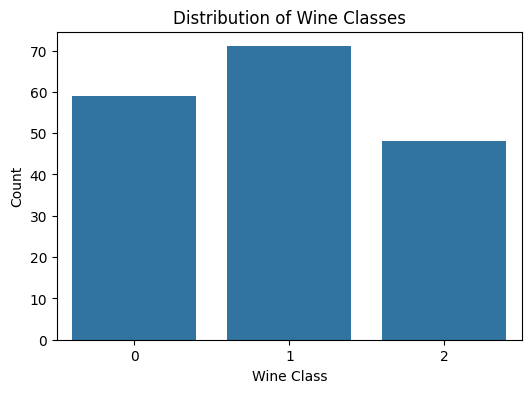

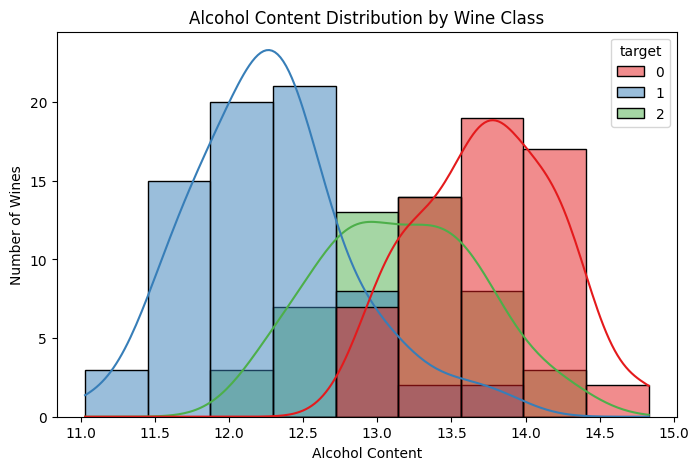

In [8]:
# 1. Visualize the distribution of the target classes
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_wine)
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()



# Visualize Alcohol Content by Wine Class using an overlapping histplot
plt.figure(figsize=(8, 5))
sns.histplot(data=df_wine, x='alcohol', hue='target', palette='Set1', kde=True, alpha=0.5)

plt.title('Alcohol Content Distribution by Wine Class')
plt.xlabel('Alcohol Content')
plt.ylabel('Number of Wines')
plt.show()

Key Insights from EDA
* zero missing values
* dataset is fairly well-balanced. Class 1 has slightly more samples than the others
* Alcohol content is a great distinguishing feature. Class 0 generally has the highest alcohol content, Class 1 has the lowest, and Class 2 sits in the middle.

Model Training & Evaluation

In [9]:
# Import the Pipeline module
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df_wine.drop('target', axis=1)
y = df_wine['target']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:

# 3. Build the Pipeline!
# Step 1: 'scaler' applies StandardScaler
# Step 2: 'classifier' runs the Logistic Regression
wine_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(multi_class='multinomial', max_iter=1000))
])

# 4. Train the Pipeline
wine_pipeline.fit(X_train, y_train)

# 5. Make predictions
wine_preds = wine_pipeline.predict(X_test)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, wine_preds)

print("--- Pipeline Logistic Regression Results ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, wine_preds))


--- Pipeline Logistic Regression Results ---
Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


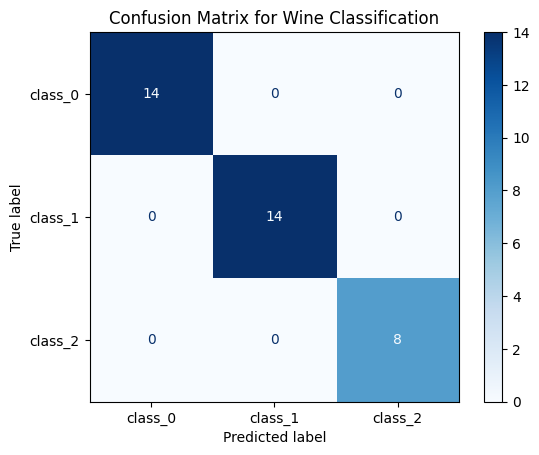

In [11]:

# Display the Confusion Matrix visually
cm = confusion_matrix(y_test, wine_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Wine Classification")
plt.grid(False) # Turns off the seaborn grid lines for the matrix
plt.show()